# Quantitative Market Analysis Framework
## Statistical Characterization, Factor Modeling and Portfolio Construction

This project presents the development of a modular quantitative framework designed to analyze financial assets from three complementary perspectives:

1. **Statistical behavior of returns**
2. **Cross-asset relationships and factor exposure**
3. **Portfolio construction and allocation**

The objective is to simulate how a real client or investment analyst would interact with a quantitative analytics library.  
Instead of isolated scripts, the system is structured into reusable classes that encapsulate financial theory, statistical modeling, and portfolio mathematics.

---

## Framework Architecture

The framework is divided into three main modules:

### 1. `market_data`
Focuses on **data preparation and statistical characterization** of financial assets.

Main responsibilities:

- Load and clean financial time series
- Compute returns
- Visualize price evolution
- Estimate statistical properties
- Identify probabilistic behavior of returns

Key analytical capabilities:

- Time series normalization and synchronization
- Descriptive statistics
- Risk metrics computation
- Distribution fitting using **Tukey–Lambda transformation**
- Tail behavior analysis

---

### 2. `capm`
Implements **cross-asset dependency modeling** using linear factor models.

Main responsibilities:

- Synchronize asset and benchmark data
- Estimate linear relationships between assets
- Measure systematic risk exposure

Mathematical tools used:

- Ordinary Least Squares (OLS)
- Linear regression:
  
\[
R_i = \alpha + \beta R_m + \varepsilon
\]

Where:

- \( \beta \) measures systematic exposure
- \( \alpha \) captures abnormal return
- \( R^2 \) evaluates explanatory power
- Correlation measures co-movement strength

This module allows comparison between assets and identification of dominant market drivers.

---

### 3. `portfolio_class`
Implements portfolio construction techniques.

Main responsibilities:

- Covariance estimation
- Portfolio allocation
- Risk diversification
- Optimization-based allocation

Mathematical foundations:

- Covariance matrices
- Mean-variance optimization
- Markowitz portfolio theory
- Constrained optimization problems

---

## Statistical and Mathematical Foundations

The framework integrates several quantitative methodologies:

### Financial Time Series Analysis
- Log/relative returns
- Temporal alignment
- Volatility representation

### Distribution Modeling — Tukey Lambda
Instead of assuming normality, returns are fitted using the Tukey-Lambda family:

$$
Q(p,\lambda)=
\begin{cases}
\log\left(\frac{p}{1-p}\right), & \lambda = 0 \\
\frac{p^\lambda-(1-p)^\lambda}{\lambda}, & \lambda \neq 0
\end{cases}
$$

The optimal parameter \( \lambda \) is obtained via PPCC (Probability Plot Correlation Coefficient) optimization:

$$
\min (1 - PPCC)^2
$$

This allows classification of return distributions into theoretical families such as:

- Cauchy (heavy tails)
- Laplace
- Logistic
- Normal
- Uniform

---

### Linear Factor Modeling
Regression analysis estimates how much an asset reacts to benchmark movements through beta exposure.

---

### Portfolio Optimization
Portfolio weights are obtained under different allocation constraints:

- Long-only allocation
- Mean-variance optimization
- Risk diversification via covariance structure

---

## Design Philosophy

The framework is built under a **client-oriented perspective**:

- Analysts interact through high-level methods
- Mathematical complexity remains encapsulated
- New metrics or models can be added modularly
- The same workflow can be adapted to any structured financial dataset

The following notebook demonstrates how an end user would naturally explore assets using this framework.

## Analytical Workflow — User Perspective

This notebook follows the logical process an investment analyst would typically perform when evaluating financial assets.

The analysis is divided into independent stages, each corresponding to one module of the framework.

---

### Part 1 — Statistical Exploration of Assets (`market_data`)

Before constructing portfolios or studying market relationships, an analyst must understand the individual behavior of each asset.

Key questions addressed in this stage:

- How does the asset evolve through time?
- What are its main risk and performance metrics?
- Does the return distribution resemble a known probabilistic model?
- Are tail risks present?

The `market_data` module provides a structured interface to load time series, visualize prices, compute statistics, and estimate the probabilistic structure of returns.

The objective of this section is to transform raw price data into statistically interpretable information.

---

Subsequent sections will extend the analysis toward:

- Cross-asset relationships (CAPM modeling)
- Portfolio allocation and optimization

In [8]:
# ============================================================
# PART 1 — Statistical Analysis of Individual Assets
# Module: market_data
# ============================================================

import importlib
import market_data

importlib.reload(market_data)

<module 'market_data' from '/Users/hectorastudillo/py-proyects/Quant_Finance_Project/market_data.py'>

In [9]:
# Asset to analyze
ric = "BBVA"

# Create analysis object
asset = market_data.distribution_manager(ric)

## Loading the Time Series — Parameterized Date Selection

The first step in the analysis consists of loading the financial time series associated with the selected asset.

```python
asset.load_timeseries(from_date='aaaa-mm-dd', to_date='aaaa-mm-dd')
```

This method replaces the previous interactive date filtering approach with a **parameter-based design**, allowing the analyst to explicitly define the time interval directly in the function call.

This modification improves:

* Computational efficiency (no runtime prompts)
* Reproducibility of experiments
* Script automation
* Reduction of user input errors

---

## Conceptual Objective

The purpose of this method is to construct the empirical random variable used throughout the analysis.

Internally, the function:

* Loads the raw historical dataset using the standalone `load_timeseries()` function.
* Optionally filters observations according to the specified date interval.
* Extracts the return series.
* Stores the return vector as the statistical object analyzed later.

After execution, the attribute:

```
self.vector
```

represents the realized return distribution of the asset.

---

## Parameters

### `from_date`

Starting date of the analysis window.

Format:

```
'YYYY-MM-DD'
```

If provided, the dataset will include observations **from this date onward**.

---

### `to_date`

Ending date of the analysis window.

Format:

```
'YYYY-MM-DD'
```

If provided, the dataset will include observations **up to this date**.

---

## Available Usage Scenarios

The method supports flexible subsetting depending on which parameters are specified.

---

### 1. Full historical dataset (default behavior)

```python
asset.load_timeseries()
```

Both parameters remain at their default values, therefore:

* No filtering is applied
* The entire database history is loaded

This is useful for long-term statistical characterization.

---

### 2. Specific time interval

```python
asset.load_timeseries(
    from_date="2018-01-01",
    to_date="2022-12-31"
)
```

Only observations inside the selected window are loaded.

Typical use cases:

* Crisis analysis
* Market regime comparison
* Event-driven studies

---

### 3. Open-ended interval — starting date only

```python
asset.load_timeseries(from_date="2020-01-01")
```

Behavior:

* Data is loaded from the specified starting date
* The ending date automatically becomes the latest available observation in the database

This is useful when analyzing recent market dynamics.

---

### 4. Open-ended interval — ending date only

```python
asset.load_timeseries(to_date="2019-12-31")
```

Behavior:

* Data is loaded from the earliest available observation
* Stops at the specified ending date

Useful for historical backtesting or pre-event analysis.


In [10]:
# Load time series and compute returns
asset.load_timeseries(log_returns = True, period_returns='monthly') # from_date='2026-03-02'
asset.timeseries

,date,close,close_previous,return
0,2018-02-01,7.458,7.082,0.051731
1,2018-03-01,6.790,7.458,-0.093836
2,2018-04-01,6.366,6.790,-0.064480
3,2018-05-01,6.765,6.366,0.060791
4,2018-06-01,6.018,6.765,-0.117007
...,...,...,...,...
93,2025-11-01,17.300,16.375,0.054951
94,2025-12-01,18.760,17.300,0.081020
95,2026-01-01,20.380,18.760,0.082827
96,2026-02-01,21.910,20.380,0.072389


Then we can get the statistical information selected and graph it.

<Figure size 640x480 with 0 Axes>

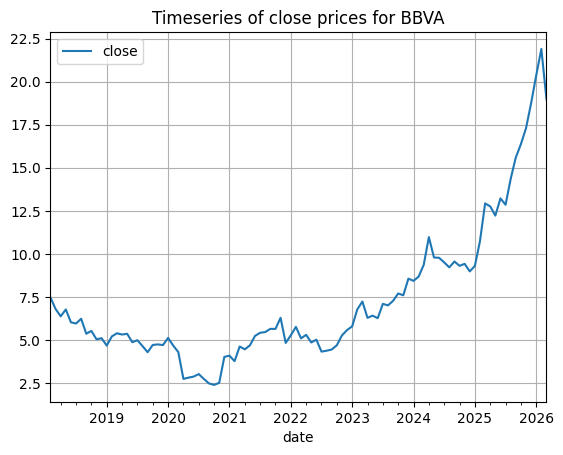

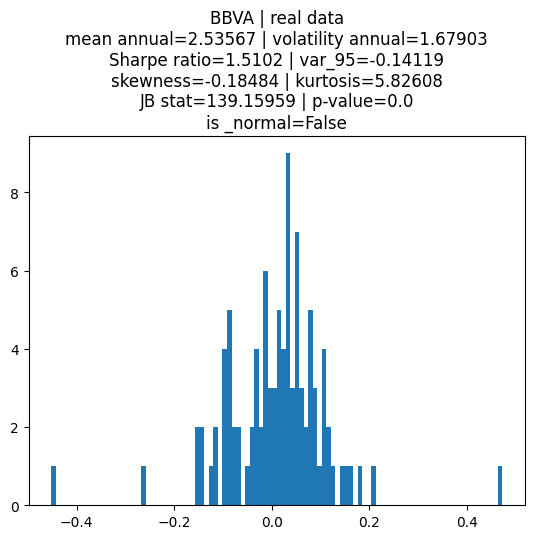

In [11]:
# Visualization of the time series
asset.plot_timeseries()

# Statistical characterization
asset.compute_stats()
asset.plot()

## Distribution Identification — Tukey Lambda Method

Financial returns rarely follow a perfect normal distribution.  
To avoid imposing a theoretical assumption, we estimate the distribution shape directly from the data.

asset.tukey_quantile(tolerance=0.05)

tolerance
Defines how close the estimated lambda must be to theoretical reference values in order to classify the distribution.
Smaller tolerance:
stricter classification
fewer matches
higher precision
Larger tolerance:
more permissive classification
broader grouping of assets

In [12]:
# Distribution identification (Tukey Lambda)
asset.tukey_quantile(tolerance=0.05)

BBVA  has the following data:
Optimal Lambda Obtained: -0.4353515625000013
PPCC obtained: 0.9818619170792602
Close to a  nan  distribution.


In [13]:
# Analysis for multiple assets (universe)
rics = ["KOFUBL", "BIMBOA", "BBVA"]

for r in rics:
    obj = market_data.distribution_manager(r)
    obj.load_timeseries()
    obj.compute_stats()
    obj.tukey_quantile()

KOFUBL  has the following data:
Optimal Lambda Obtained: 0.03478125000000014
PPCC obtained: 0.9991513779365976
Close to a  Logistic  distribution.
BIMBOA  has the following data:
Optimal Lambda Obtained: -0.07978515624999918
PPCC obtained: 0.9977891110278971
Close to a  Hyperbolic Secant  distribution.
BBVA  has the following data:
Optimal Lambda Obtained: -0.21694531250000032
PPCC obtained: 0.9984311249242921
Close to a  Laplace  distribution.


# Universe-Level Distribution Analysis

So far, the analysis has focused on individual assets.  
However, quantitative research frequently requires understanding the statistical behavior of an entire market universe.

Two complementary diagnostics are introduced:

### 1. Tukey Lambda Classification

The function `get_all_lambda()` estimates the optimal Tukey–Lambda parameter for every asset stored in the database directory.

This allows us to classify assets according to their empirical distribution shape:

- Heavy-tailed assets (riskier extreme behavior)
- Near-normal assets
- Flat or uniform-like distributions

Instead of assuming normality, this procedure lets the data determine the probabilistic structure.

---

### 2. Higher Moments Analysis

Financial returns are known to deviate from Gaussian assumptions.

The function `get_all_kurtosis_skewness()` computes:

- Mean and median returns
- Kurtosis (tail thickness)
- Skewness (asymmetry)
- Sample size and observation window

These metrics help identify:

- Assets prone to extreme events (high kurtosis)
- Downside risk asymmetry (negative skewness)

Together, both analyses provide a distributional map of the market universe.

In [14]:
# ============================================================
# Universe-Level Statistical Analysis
# Functions from market_data module
# ============================================================

# Tukey Lambda estimation for entire universe
df_lambda = market_data.get_all_lambda(
    directory="market_universe",
    tolerance=0.03,
    printMetrics=False
)

df_lambda.head()

,ric,lambda,tipo
0,KOFUBL,0.034781,NaN
1,UVIX,-0.303375,NaN
2,TUM26,-0.305762,NaN
3,GCARSOA1,-0.054004,Hyperbolic Secant
4,MSCI_EM,-0.133930,Laplace


In [15]:
# Kurtosis and Skewness analysis for all assets
df_moments = market_data.get_all_kurtosis_skewness(
    ric=ric,
    directory="market_universe"
)

df_moments.head()

,ric,%median,%mean,kurtosis,skewness,sample-size,from,up to
0,KOFUBL,0.024313,0.059149,0.569228,0.166380,1245,2021-01-05,2025-12-11
1,KIMBERA,0.000000,0.023189,1.202233,0.172412,1245,2021-01-05,2025-12-11
2,GFINBURO,0.027300,0.078633,1.305442,0.314476,1245,2021-01-05,2025-12-11
3,USDEUR,0.000000,0.002957,1.663719,-0.086584,2138,2018-01-02,2026-03-12
4,DXY,0.000000,0.004635,1.815711,-0.148771,2129,2018-01-02,2026-03-13


# CAPM Model — Correlation, Beta and Linear Regression Framework

This module introduces the **model class**, designed to study the statistical relationship between two financial assets through linear regression.

The objective is to quantify:

- Linear dependence between assets
- Sensitivity (Beta) relative to a benchmark
- Explanatory power of one asset over another
- Statistical significance of the relationship

Conceptually, this class implements a practical interpretation of the **Capital Asset Pricing Model (CAPM)** using empirical return distributions.

---

## General Workflow

A typical analysis follows this structure:

```python
security = "AMZN"
benchmark = "^SPX"

analysis = capm.model(security, benchmark)

analysis.synchronise_timeseries()
analysis.compute_linear_reg()
analysis.plot_linear_reg()
```

---

## Class Initialization

### `model(security, benchmark, decimals=5)`

### Parameters

**security**  
Asset whose behavior we want to explain.

**benchmark**  
Reference asset used as explanatory variable.  
Economically, the benchmark explains the security.

**decimals**  
Number of decimals used when storing regression results.

---

## Conceptual Interpretation

The regression estimated is:

$$
R_{security} = \alpha + \beta R_{benchmark} + \epsilon
$$

where:

- **β (beta)** measures sensitivity to the benchmark.
- **α (alpha)** measures abnormal return not explained by the benchmark.

---

## Method: `synchronise_timeseries()`

```python
analysis.synchronise_timeseries(extremeValues=False)
```

### Objective
Financial assets rarely share identical trading calendars.  
This method aligns both datasets by matching dates so regression is computed only on comparable observations.

### Parameters

**extremeValues : bool**

- If True, allows preprocessing rules defined inside market_data.
- If False, raw synchronized returns are used.

### Output

Creates internally:

`self.timeseries`

containing:

- aligned dates
- close prices
- synchronized returns

---

## Method: `plot_timeseries()`

```python
analysis.plot_timeseries()
```

### Objective
Visual comparison of both assets' price evolution.

### Description

- Benchmark plotted on primary axis.
- Security plotted on secondary axis.

Useful for detecting structural co-movements before statistical modeling.

### Typical Use Cases

- Regime comparison
- Divergence detection
- Structural breaks

---

## Method: `compute_linear_reg()`

```python
analysis.compute_linear_reg()
```

### Objective
Estimate the linear regression between benchmark and security returns.

### Internal Procedure

Extract synchronized returns:

- `return_x` → benchmark
- `return_y` → security

Apply:

`scipy.stats.linregress()`

Store statistical metrics.

### Stored Outputs

- `self.beta` → slope coefficient
- `self.alpha` → intercept
- `self.correlation` → Pearson correlation
- `self.r_squared` → explanatory power
- `self.p_value` → hypothesis test significance
- `self.predictor_linreg` → fitted regression line

### Interpretation

- High beta → strong sensitivity to benchmark
- High $R^2$ → benchmark explains large portion of variance
- Low p-value → statistically meaningful relationship

---

## Method: `plot_linear_reg()`

```python
analysis.plot_linear_reg()
```

### Objective
Visualize the regression structure.

### Description

Produces:

- Scatterplot of returns
- Estimated regression line
- Statistical summary in title

### Analytical Value

Allows visual validation of:

- Linearity assumption
- Outliers
- Volatility clustering

---



## Conceptual Warning

Correlation direction matters:

A benchmark explains an asset.  
An index does not necessarily explain individual securities symmetrically.

Example:

- BIMBOA explains MXX
- MXX does not necessarily explain BIMBOA

---

## Output

Creates:

`self.allCorrelationsDf`

containing:

- benchmark
- correlation
- beta
- $r^2$
- compared security

Sorted by highest correlation.

In [2]:
import capm
import importlib
importlib.reload(capm)

<module 'capm' from '/Users/hectorastudillo/py-proyects/Quant_Finance_Project/capm.py'>

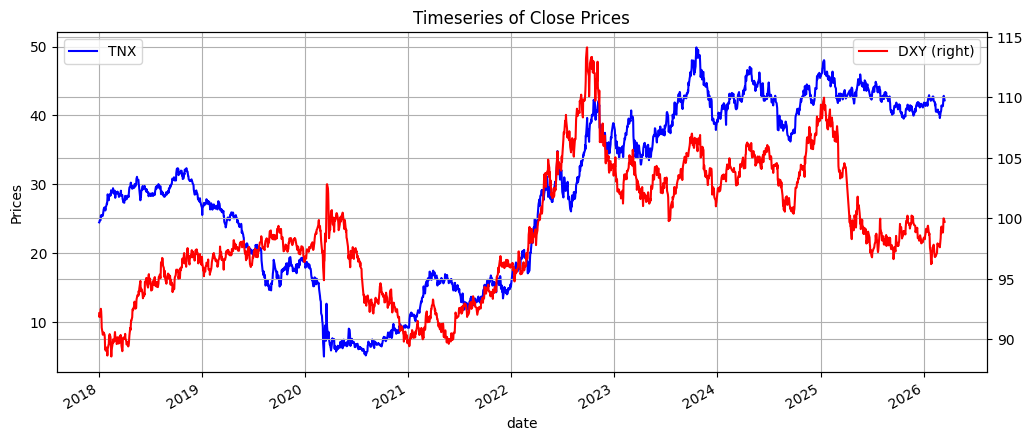

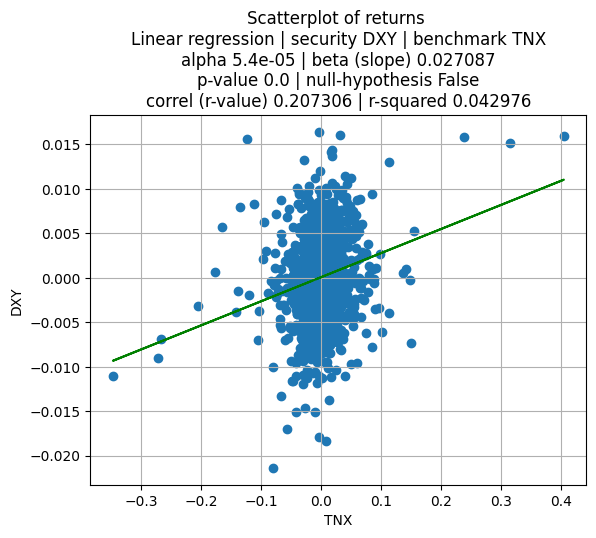

In [27]:
security = "DXY"
benchmark = "TNX"

summary = capm.model(security, benchmark, 6)

summary.synchronise_timeseries(log_returns= True, period_returns='daily') # from_date='2020-01-01', to_date='2021-01-01'
summary.plot_timeseries()

summary.compute_linear_reg()
summary.plot_linear_reg()

In [4]:
import pandas as pd

times = ['daily', 'weekly', 'monthly']
index = ['correlation', 'r2', 'beta']

dic = {}

security = "BBVA"
benchmark = "MSCIW"

summary = capm.model(security, benchmark, 6)


for i in times:
    summary.synchronise_timeseries(log_returns=True, period_returns=i)
    summary.compute_linear_reg()
    dic[i] = {
        'correlation': summary.correlation,
        'r2': summary.r_squared,
        'beta': summary.beta
    }

explorer = pd.DataFrame(dic)

# asegurar el orden del índice
explorer = explorer.loc[index]

print(explorer)

                daily    weekly   monthly
correlation  0.483445  0.506354  0.517526
r2           0.233719  0.256394  0.267833
beta         1.030121  1.096353  1.304019


## get_all_correlations()

### Objective

`get_all_correlations()` computes the cross-sectional statistical relationship between a benchmark and a set of assets.

It generalizes the original static implementation by allowing:

- Custom benchmark selection
- Custom subset of RICs
- Flexible date window definition
- Optional CSV export

This transforms the method into a reusable cross-asset statistical scanner.

---

### Conceptual Note

Correlation direction matters.

A benchmark explains an asset — not necessarily the other way around.

Example:
- A stock may explain an index.
- An index does not symmetrically explain each constituent.

This method evaluates assets **relative to a chosen benchmark**.

---



### Output Structure

The method builds and stores:

```python
self.allCorrelationsDf
```

Sorted by descending correlation.

Columns:

| Column | Meaning |
|--------|---------|
| benchmark | Explanatory variable |
| correlation | Pearson correlation |
| beta | Linear regression beta |
| r2 | Explained variance |
| security | Asset analyzed |
| min_date | First observation used |
| max_date | Last observation used |

The date columns indicate the **effective estimation window**, which may differ across assets due to listing dates or missing data.

---


### Interpretation

This method converts a potentially manual O(n²) comparison into a structured and reproducible quantitative workflow, enabling scalable empirical asset pricing analysis.

In [16]:
from capm import get_correlations

benchmarks = ['SPX', 'IBEX', 'MXX', 'USDMXN', 'USDEUR', 'FEI', 'TUM26', 'TLT', 'IEF', 'SHY', 'TNF10', 'BEU30', 'VIX', 'WTI', 'GOLD', 'SIK6'] # We can put stock market indices here 
rics = ['BBVA'] 

# BBVA - ['MSCIW', 'BBVA', 'IBEX', 'SPX', 'QUAL', 'IVW', 'NASDAQ']
df = get_correlations(specific_rics=['BBVA', 'IBEX'], specific_benchmarck=['MSCIW'],  orderby = 'r2')
# from_date = '2020-02-12', to_date = '2021-02-12'
print(df)
# If you want to get all the correlations using the entire universe of rics in regard to the specified benchmark, only call the function without arguments.

# BOTH ARE IMPORTANT 
# bench.    corr.    beta.    r2.         sec.  
# BBVA      0.80517  0.43203  0.64830     IBEX  ... if IBEX +1% then BBVA ≈ +0.43%
# IBEX      0.80517  1.50062  0.64830     BBVA *** More used: Security vs Benchmark - BBVA vs IBEX
# BBVA return = market factor (IBEX) + bank factor + idiosyncratic noise

  benchmark  correlation     beta       r2 security   min_date   max_date
0     MSCIW      0.47691  1.01784  0.22745     BBVA 2018-01-03 2026-03-16
1     MSCIW      0.62167  0.71381  0.38647     IBEX 2020-02-04 2026-03-16


In [20]:
df1 = get_correlations(specific_benchmarck=['TLT'], orderby = 'correlation')

print(df1)

   benchmark  correlation     beta       r2 security   min_date   max_date
0        TLT     -0.86618 -1.97605  0.75026    BEU30 2018-01-03 2026-03-05
1        TLT     -0.78374 -2.58071  0.61425      TNX 2018-01-03 2026-03-05
2        TLT     -0.50252 -2.06420  0.25253    US02Y 2018-01-03 2026-03-05
3        TLT     -0.22546 -0.50208  0.05083     BBVA 2018-01-03 2026-03-05
4        TLT     -0.20276 -0.08621  0.04111      DXY 2018-01-03 2026-03-05
..       ...          ...      ...      ...      ...        ...        ...
63       TLT      0.44971  0.05676  0.20224    TUM26 2018-01-03 2026-03-05
64       TLT      0.56905  0.06567  0.32382      SHY 2018-01-03 2026-03-05
65       TLT      0.86668  0.41614  0.75113    TNF10 2018-01-03 2026-03-05
66       TLT      0.91064  0.40735  0.82927      IEF 2018-01-03 2026-03-05
67       TLT      1.00000  1.00000  1.00000      TLT 2018-01-03 2026-03-05

[68 rows x 7 columns]


## Normalized Price Time Series - Function from capm.py

This function plots normalized price time series for a group of assets.  
The series are first filtered by the selected date window and then normalized so that the first observation within that window equals a chosen base value.

This normalization allows assets with different price levels to be compared more clearly in terms of their relative performance.

The transformation is defined as:

$$
Price_{norm} = \frac{Price_t}{Price_{from}} \times base\_value
$$

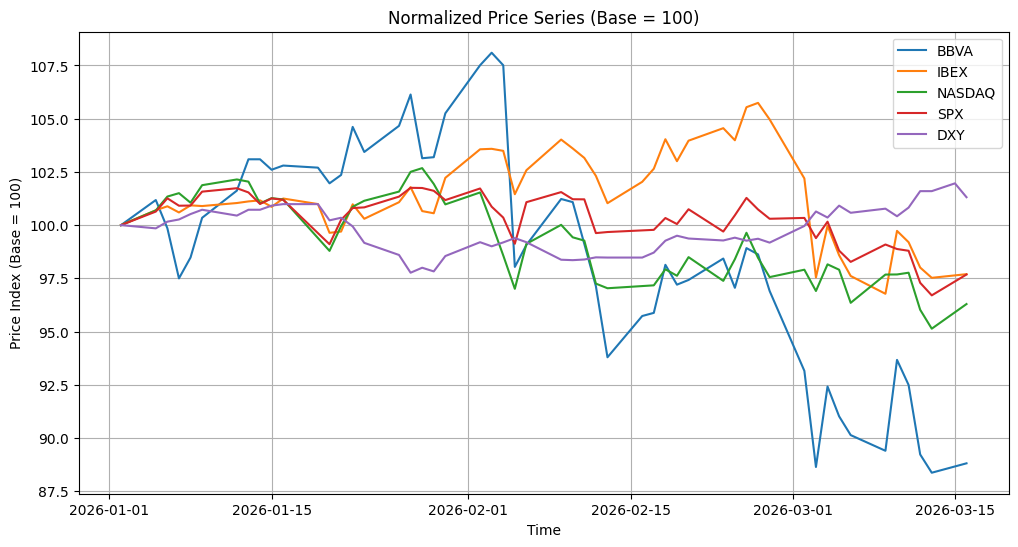

In [6]:
from capm import plot_normalized_timeseries
rics = ["BBVA","IBEX", "NASDAQ","SPX", 'DXY']
plot_normalized_timeseries(
    rics,
    from_date="2026-01-01",
    base_value=100
)

## Macro Dashboard — Key Indicators

| Asset   | What it Measures                  |
|---------|----------------------------------|
| DXY     | U.S. dollar strength             |
| **TNX** | 10-year Treasury yield           |
| US02Y   | Fed policy expectations          |
| Gold    | Inflation expectations           |
| Nasdaq  | Liquidity / risk appetite        |

---

## Typical Market Read

A common setup:

- TNX increases  
- DXY increases  
- Nasdaq decreases  
- Gold decreases  

$\Rightarrow$ **Interpretation:** Tighter financial conditions

---

## Key Macro Signal

The most important variable is:

**US10Y (TNX) trending higher**

When the 10-year yield rises, it typically implies:

- Higher rates for longer  
- Reduced liquidity  
- Stronger U.S. dollar  

$\Rightarrow$ **Conclusion:**  
**TNX** acts as a leading signal in the macro environment

---

## Key Macro Relationship

One of the most stable macro relationships:

**TNX increases $\Rightarrow$ Gold decreases**

This occurs because higher yields increase the opportunity cost of holding non-yielding assets such as gold.

---

## ETFs for Rate Exposure

If you prefer equity-like instruments:

- **TLT** — Long-term bonds (20+ years)  
- **IEF** — Medium-term bonds (7–10 years)  
- **SHY** — Short-term bonds (1–3 years)  

---

## Yield Tickers (TradingView)

| Yield    | Ticker   |
|----------|----------|
| 13 weeks | `.IRX`   |
| 5 years  | `.FVX`   |
| 10 years | **`.TNX`** |
| 30 years | `.TYX`   |

---

## Understanding TNX

- **Ticker:** `.TNX`  
- **Definition:** 10-year U.S. Treasury yield  

**Example:**

- TNX = 43.50  
$\Rightarrow$ Yield = **4.35%**

---

## Yield Curve Insight

A commonly used macro indicator:

**10Y − 2Y spread**

That is:
TNX - US02Y

**Interpretation:**

- Positive spread $\Rightarrow$ Normal curve (expansion)  
- Negative spread $\Rightarrow$ Inverted curve (recession risk)

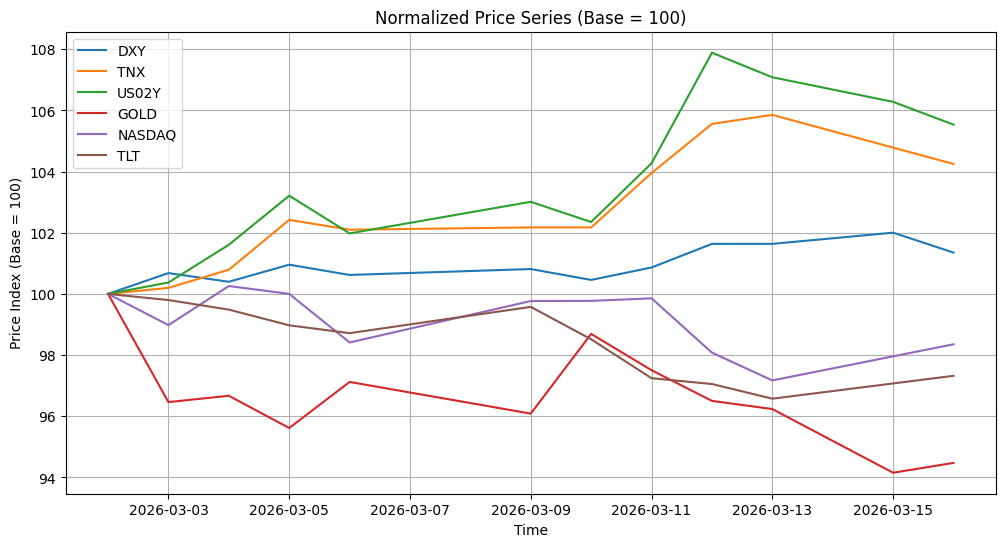

In [23]:
from capm import plot_normalized_timeseries
rics = ["DXY","TNX", "US02Y", "GOLD", "NASDAQ", "TLT"]
plot_normalized_timeseries(
    rics,
    from_date="2026-03-01",
    base_value=100
)

En realidad:
acciones → índice
pero en modelos financieros usamos:
índice → acciones
porque el índice representa el factor común.

# Hedge Class — Delta & Beta Neutralization Framework

## Introduction

The `hedge` class implements a systematic framework for constructing **delta-neutral and beta-neutral hedges** relative to a chosen benchmark.

From an investor’s perspective, this model answers a practical question:

> If I hold a position exposed to market movements, how can I neutralize that exposure using other securities?

The framework assumes:

- You hold a position in a security.
- That position has market exposure (beta).
- You want to hedge both:
  - Absolute capital exposure (delta in USD)
  - Systematic exposure (beta relative to a benchmark)

The hedge is constructed using **at least two securities**, ensuring a unique solution to the linear system.

---

# Conceptual Structure

The class separates the problem into two components:

### 1️⃣ Original Position
- `position_security`
- `position_delta_usd`
- `position_beta`
- `position_beta_usd`

This defines the exposure to be neutralized.

### 2️⃣ Hedge Instruments
- `hedge_securities`
- `hedge_betas`
- `hedge_weights`
- `hedge_delta_usd`
- `hedge_beta_usd`

These define how the hedge offsets exposure.

---

# Constructor

```python
hedge(position_security,
      position_delta_usd,
      benchmark,
      hedge_securities)
```

### Arguments

- `position_security` → Asset where liquidity is absorbed.
- `position_delta_usd` → Dollar exposure (positive value).
- `benchmark` → Reference asset for beta computation.
- `hedge_securities` → List of securities used for hedging (minimum two).

---

# Method 1 — compute_betas()

```python
compute_betas()
```

### Purpose

Computes:

- Beta of the position relative to benchmark.
- Beta-scaled USD exposure.
- Betas of hedge instruments.

### Internally

```
position_beta = compute_beta(position_security, benchmark)
position_beta_usd = position_beta * position_delta_usd
```

For hedge securities:

```
beta_i = compute_beta(security_i, benchmark)
```

This prepares the system for optimization or matrix solving.

---

# Method 2 — compute_hedge_weights()

```python
compute_hedge_weights(regularisation=0)
```

### Purpose

Numerical optimization approach using `scipy.optimize.minimize`.

It minimizes a cost function that penalizes:

- Residual delta exposure
- Residual beta exposure
- Optional regularization term

### Why optimization?

This approach allows:

- Regularization
- Soft constraints
- Extension to more than 2 hedge assets

It starts from an initial guess:

```
x0 = - position_delta_usd / N
```

Then finds optimal weights.

---

# Method 3 — compute_hedge_weights_model1()

```python
compute_hedge_weights_model1()
```

### Purpose

Closed-form linear algebra solution.

Solves the system:

Delta Neutrality:
Σ w_i = - position_delta_usd

Beta Neutrality:
Σ (beta_i * w_i) = - position_beta_usd

In matrix form:

```
[ 1      1   ]   [ w1 ]   =   [ -position_delta_usd ]
[ beta1 beta2 ]   [ w2 ]       [ -position_beta_usd ]
```

Solution:

```
weights = inv(matrix) · targets
```

This method guarantees exact neutrality (if matrix invertible).

---

# Practical Investor Interpretation

If an investor holds:

- Long $1,000,000 in a stock
- Beta = 1.2 relative to index

Then:

- Beta USD exposure = 1,200,000

The hedge must offset:

- -1,000,000 delta
- -1,200,000 beta USD

The system determines how much to short (or long) in hedge instruments.

---

# Workflow Example

## Step 1 — Define Position

```python
position = 'GCARSOA1'
delta_usd = 1_000_000
benchmark = 'MXX'
hedge_assets = ['GFNORTEO', 'WALMEX']

h = hedge(position, delta_usd, benchmark, hedge_assets)
```

---

## Step 2 — Compute Betas

```python
h.compute_betas()

h.position_beta
h.position_beta_usd
h.hedge_betas
```

---

## Step 3A — Optimization-Based Hedge

```python
h.compute_hedge_weights()

h.hedge_weights
h.hedge_delta_usd
h.hedge_beta_usd
```

---

## Step 3B — Closed-Form Hedge

```python
h.compute_hedge_weights_model1()

h.hedge_weights
h.hedge_delta_usd
h.hedge_beta_usd
```

---

# Interpretation of Results

- `hedge_weights` → Dollar amounts to allocate to hedge securities
- `hedge_delta_usd` → Should offset original delta
- `hedge_beta_usd` → Should offset original beta exposure

If properly constructed:

```
Net Delta ≈ 0
Net Beta Exposure ≈ 0
```

---

# Typical Use Cases

- Market-neutral strategies
- Beta isolation
- Cross-asset arbitrage preparation
- Liquidity sourcing
- Risk overlay construction
- Pre-portfolio optimization risk cleaning

---

# Final Insight

This class transforms hedging from an intuitive manual adjustment into a **structured quantitative risk-engineering process**.

It bridges:

- CAPM intuition
- Linear algebra
- Optimization theory
- Practical portfolio risk control

In a real investment workflow, this becomes the core engine behind systematic exposure management.